# 8 — Policy Gradients and PPO

Letting the algorithm search · SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/08-ppo/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** Not for training —
    MuJoCo renders video through EGL on Colab, and that needs the GPU
    runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

This lab **trains** and takes a few minutes to run. That is normal.

## Today we finally train something

Last week we wrote the problem. Today we search it.

Deliberately, **we do not start with the humanoid.** We start with a
cart and a pole, because you need to know what a *healthy* learning
curve looks like before you can diagnose a sick one.

By the end of the lecture we will point PPO at the G1 — and watch it get
**worse**. That is the intended result, and it names next week.

------------------------------------------------------------------------

## The idea

We want $\theta$ maximising
$J(\theta) = \mathbb{E}_{\tau\sim\pi_\theta}[R(\tau)]$.

The problem: the environment is not differentiable. We cannot
backpropagate through contact, friction, or a physics engine.

The **policy gradient theorem** goes around it:

$$\nabla_\theta J(\theta) = \mathbb{E}\left[\sum_t \nabla_\theta \log \pi_\theta(a_t\mid s_t)\; R_t\right]$$

Read it as an instruction: **make the actions that preceded high return
more likely.** The gradient touches only the policy network, never the
simulator.

------------------------------------------------------------------------

## The idea, in one dimension

A Gaussian policy over a single action,
$\pi_\theta(a) = \mathcal N(\mu, \sigma^2)$, so
$\nabla_\mu \log\pi(a) = (a-\mu)/\sigma^2$: **the gradient points from
the mean toward each sample**. Weight those pointers by return and add
them up.

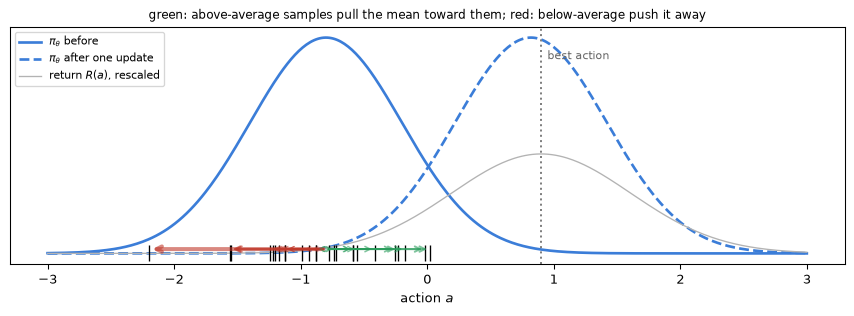

mean moved from -0.80 to +0.82, toward the best action at +0.90

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
mu, sigma, a_star = -0.8, 0.6, 0.9
samples = rng.normal(mu, sigma, 25)
R = -(samples - a_star) ** 2                          # the environment's opinion
adv = R - R.mean()                                    # with a baseline
step = 0.6 * np.mean(adv * (samples - mu) / sigma**2) # one REINFORCE update on mu

fig, ax = plt.subplots(figsize=(9, 3.4))
a = np.linspace(-3, 3, 400)
ax.plot(a, np.exp(-(a - mu)**2 / (2 * sigma**2)), color="#3b7dd8", lw=2, label=r"$\pi_\theta$ before")
ax.plot(a, np.exp(-(a - mu - step)**2 / (2 * sigma**2)), color="#3b7dd8", lw=2, ls="--", label=r"$\pi_\theta$ after one update")
ax.plot(a, np.exp(R.max()) * np.exp(-(a - a_star)**2), color="0.7", lw=1, label="return $R(a)$, rescaled")
for s, w in zip(samples, adv):
    ax.annotate("", xy=(s, 0.02), xytext=(mu, 0.02),
                arrowprops=dict(arrowstyle="->", lw=0.5 + 2.5 * abs(w) / abs(adv).max(),
                                color="#2a9d5c" if w > 0 else "#c0392b", alpha=0.6))
ax.plot(samples, np.zeros_like(samples), "k|", ms=12)
ax.axvline(a_star, color="0.5", ls=":"); ax.text(a_star + 0.05, 0.9, "best action", fontsize=8, color="0.4")
ax.set_xlabel("action $a$"); ax.set_yticks([]); ax.legend(fontsize=8, loc="upper left")
ax.set_title("green: above-average samples pull the mean toward them; red: below-average push it away", fontsize=9)
fig.tight_layout(); plt.show()
print(f"mean moved from {mu:+.2f} to {mu + step:+.2f}, toward the best action at {a_star:+.2f}")

No derivative of $R$ was taken. The environment only *scored* the
samples.

------------------------------------------------------------------------

## REINFORCE, in full

That equation is about twenty lines of code.

In [2]:
try:
    import soc4180
    import torch
except ImportError:
    %pip install -q "soc4180[rl] @ git+https://github.com/gnoejh/soc4180.git"
    import soc4180, torch

import time, warnings
import numpy as np
import torch.nn as nn
import gymnasium as gym
warnings.filterwarnings("ignore")

torch.manual_seed(0); np.random.seed(0)
env = gym.make("CartPole-v1")
policy = nn.Sequential(nn.Linear(4, 64), nn.Tanh(), nn.Linear(64, 2))
opt = torch.optim.Adam(policy.parameters(), lr=1e-2)

def episode():
    obs, _ = env.reset(); logps, rewards = [], []
    while True:
        dist = torch.distributions.Categorical(
            logits=policy(torch.as_tensor(obs, dtype=torch.float32)))
        action = dist.sample()
        logps.append(dist.log_prob(action))
        obs, r, terminated, truncated, _ = env.step(int(action))
        rewards.append(r)
        if terminated or truncated:
            return torch.stack(logps), rewards

def discounted(rewards, gamma=0.99):
    R, out = 0.0, []
    for r in reversed(rewards):
        R = r + gamma * R; out.append(R)
    return torch.tensor(list(reversed(out)), dtype=torch.float32)

------------------------------------------------------------------------

## Training it

In [3]:
env.reset(seed=0); env.action_space.seed(0)
t0 = time.time(); history = []

for update in range(100):
    logps, returns = [], []
    for _ in range(8):                          # a batch of episodes per update
        lp, rewards = episode()
        logps.append(lp); returns.append(discounted(rewards))
        history.append(sum(rewards))

    lp = torch.cat(logps); ret = torch.cat(returns)
    ret = (ret - ret.mean()) / (ret.std() + 1e-8)      # baseline: centre the returns

    loss = -(lp * ret).mean()                   # ascend the gradient
    opt.zero_grad(); loss.backward(); opt.step()

print(f"{len(history)} episodes in {time.time()-t0:.0f}s")
for k in (100, 300, 500, len(history)):
    print(f"  by episode {k:3d}: mean return over the previous 50 = {np.mean(history[k-50:k]):6.1f}")

800 episodes in 178s
  by episode 100: mean return over the previous 50 =   60.0
  by episode 300: mean return over the previous 50 =  381.2
  by episode 500: mean return over the previous 50 =  486.9
  by episode 800: mean return over the previous 50 =  488.6

Two details carry this. **Returns are centred** — subtracting the mean
is a *baseline*, and without it the thing barely moves. And updates use
a **batch of eight episodes**: with one episode per update the variance
is so large that training frequently goes nowhere at all.

------------------------------------------------------------------------

## Look at the curve, not the last number

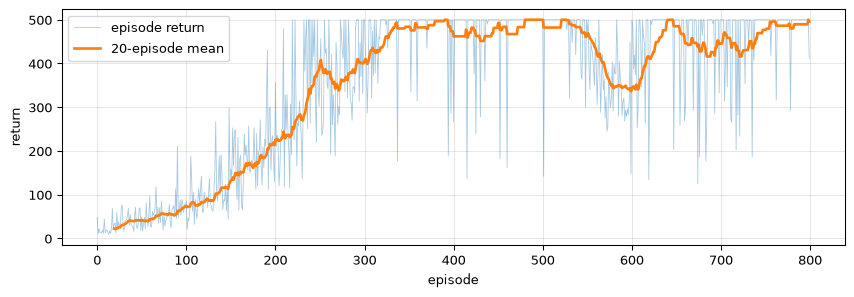

In [4]:
import matplotlib.pyplot as plt

smooth = np.convolve(history, np.ones(20)/20, mode="valid")
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(history, lw=0.6, alpha=0.4, label="episode return")
ax.plot(np.arange(len(smooth)) + 19, smooth, lw=2, label="20-episode mean")
ax.set_xlabel("episode"); ax.set_ylabel("return"); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

It climbs, but raggedly, and it dips. **That is not a bug — it is
REINFORCE.** The gradient is estimated from a handful of trajectories,
so it is noisy, and an unlucky batch can undo real progress.

Try it with a batch of one and you will often see no learning
whatsoever. The algorithm is correct; the estimator is just terrible.

------------------------------------------------------------------------

## Reducing the variance

Three fixes, in the order the field found them:

1.  **Baseline.** Subtract $b(s)$ from the return. It does not bias the
    gradient and cuts variance sharply. We used the batch mean; a
    learned value function $V(s)$ is better.
2.  **Advantage.** With $V(s)$ learned, use $A_t = R_t - V(s_t)$: “was
    this action better than average *from here*?” That is
    **actor-critic**.
3.  **Reuse the data.** REINFORCE throws each trajectory away after one
    gradient step. That is wasteful when each step costs a physics
    simulation.

Reusing data is dangerous: after a few updates the policy no longer
matches the data that was collected. **PPO exists to make that reuse
safe.**

------------------------------------------------------------------------

## Why a baseline is free

Subtracting any $b(s)$ from the return changes nothing in expectation:

$$\mathbb E_{a\sim\pi}\big[\nabla_\theta \log\pi_\theta(a\mid s)\; b(s)\big]
= b(s)\,\nabla_\theta \sum_a \pi_\theta(a\mid s)
= b(s)\,\nabla_\theta 1 = 0 .$$

So the gradient estimate stays **unbiased**, while its variance drops —
because $\nabla\log\pi \cdot (R - b)$ is small whenever $R$ is close to
$b$, which is most of the time. The best $b(s)$ is the expected return
from $s$, i.e. the value function; the batch mean we used on CartPole is
the poor man’s version.

The advantage $A_t = R_t - V(s_t)$ is this idea taken seriously, and it
is the quantity PPO’s objective is written in.

------------------------------------------------------------------------

## PPO in one slide

Let
$r_t(\theta) = \dfrac{\pi_\theta(a_t\mid s_t)}{\pi_{\theta_{\text{old}}}(a_t\mid s_t)}$
— how much the new policy has changed its mind.

$$L = \mathbb{E}\left[\min\left(r_t A_t,\;\ \text{clip}(r_t, 1-\epsilon, 1+\epsilon)\,A_t\right)\right]$$

The clip removes any incentive to push $r_t$ beyond $1\pm\epsilon$: once
an action is far enough more likely, making it *more* likely buys
nothing.

**Small, safe steps, taken many times.** That is the entire idea, and it
is why PPO is the default for locomotion.

------------------------------------------------------------------------

## The clip, drawn

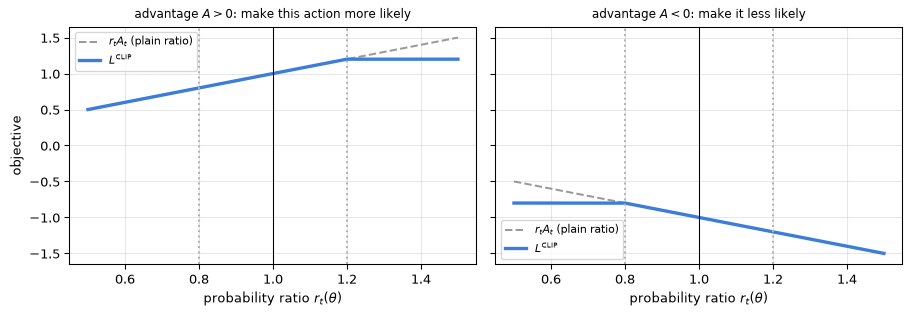

In [5]:
r = np.linspace(0.5, 1.5, 300); eps = 0.2
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.6, 3.4), sharey=True)
for ax, A, title in ((ax0, +1.0, "advantage $A > 0$: make this action more likely"),
                     (ax1, -1.0, "advantage $A < 0$: make it less likely")):
    unclipped = r * A
    clipped = np.minimum(r * A, np.clip(r, 1 - eps, 1 + eps) * A)
    ax.plot(r, unclipped, color="0.6", ls="--", lw=1.5, label=r"$r_t A_t$ (plain ratio)")
    ax.plot(r, clipped, color="#3b7dd8", lw=2.5, label=r"$L^{\mathrm{CLIP}}$")
    ax.axvline(1 - eps, color="0.7", ls=":"); ax.axvline(1 + eps, color="0.7", ls=":")
    ax.axvline(1, color="k", lw=0.8)
    ax.set_xlabel(r"probability ratio $r_t(\theta)$"); ax.set_title(title, fontsize=9)
    ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="upper left" if A > 0 else "lower left")
ax0.set_ylabel("objective")
fig.tight_layout(); plt.show()

Left: once the action is $1+\epsilon$ times more likely than it was, the
objective goes **flat** — no gradient, no incentive to keep pushing.
Right: the mirror image. In both plots the flat part is on the side the
update would move toward, which is exactly the side that needs a brake.

------------------------------------------------------------------------

## PPO on a continuous task

CartPole has two discrete actions. A robot has twelve continuous ones,
so let us move to a continuous problem — still trivial, but the right
shape.

In [6]:
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

t0 = time.time()
pend = gym.make("InvertedPendulum-v5")
model = PPO("MlpPolicy", pend, verbose=0, seed=0, device="cpu")
before, _ = evaluate_policy(model, pend, n_eval_episodes=10, warn=False)
model.learn(total_timesteps=80_000)
after, _ = evaluate_policy(model, pend, n_eval_episodes=10, warn=False)
print(f"InvertedPendulum: return {before:.1f} -> {after:.1f}  ({time.time()-t0:.0f}s)")

InvertedPendulum: return 23.1 -> 1000.0  (104s)

Solved, cleanly, in about a minute and a half. **Remember this
feeling.**

------------------------------------------------------------------------

## Now the humanoid

Same algorithm, same defaults, our environment from last week.

In [7]:
from soc4180.envs import G1WalkEnv

env_g1 = G1WalkEnv()
t0 = time.time()
agent = PPO("MlpPolicy", env_g1, verbose=0, seed=0, device="cpu")
before, _ = evaluate_policy(agent, env_g1, n_eval_episodes=5, warn=False)
print(f"untrained : {before:7.1f}      (hold-the-crouch baseline = 774)")
agent.learn(total_timesteps=30_000)
after, _ = evaluate_policy(agent, env_g1, n_eval_episodes=5, warn=False)
print(f"30k steps : {after:7.1f}      ({time.time()-t0:.0f}s)")

untrained :   774.3      (hold-the-crouch baseline = 774)
30k steps :    94.7      (73s)

Two things in those numbers, and both matter.

------------------------------------------------------------------------

## The untrained policy already scores 774

That is exactly the “do nothing” baseline from 07 — and it is **by
design**.

Residual actions mean an untrained network, whose outputs hover near
zero, commands the nominal crouch. It stands there, collects the alive
bonus and the upright reward, and scores well.

That is the Week 7 action-design decision paying off: **the policy
starts from competence rather than from a heap on the floor.**

It also sets a cruel bar. Any learning must beat 774, and the easiest
way to score 774 is to do nothing at all.

------------------------------------------------------------------------

## Training made it worse

774 → 95. **Thirty thousand steps of learning produced a policy far
worse than the untrained one.** Look at what it actually does:

In [8]:
obs, _ = env_g1.reset(seed=0); steps = 0
while True:
    action, _ = agent.predict(obs, deterministic=True)
    obs, r, terminated, truncated, info = env_g1.step(action)
    steps += 1
    if terminated or truncated:
        break
print(f"steps survived   : {steps} of {env_g1.max_steps}")
print(f"travelled        : {env_g1.data.qpos[0]:+.3f} m")
print(f"forward velocity : {info['forward_velocity']:+.3f} m/s  "
      f"(the reward asks for {env_g1.target_velocity})")
print(f"outcome          : {'FELL' if terminated else 'survived'}")

steps survived   : 46 of 500
travelled        : +0.478 m
forward velocity : +1.283 m/s  (the reward asks for 0.5)
outcome          : FELL

It **lunges**. Velocity far past the target, a metre of ground covered,
and then it goes down.

------------------------------------------------------------------------

## Is the reward to blame?

The obvious story is that our reward rewards diving. **Check it before
believing it** — the reward is only four terms, so evaluate them by
hand:

In [9]:
def per_step_reward(v, target=0.5):
    return 1.5*np.exp(-((v-target)**2)/0.25) + 0.5*1.0 + 0.5   # upright + alive

for v, steps, label in ((0.5, 500, "walk at the target"),
                        (0.0, 500, "stand still"),
                        (1.283, 46, "lunge, then fall")):
    print(f"  {label:22s} {per_step_reward(v):.3f}/step x {steps:3d} = {per_step_reward(v)*steps:7.1f}")

  walk at the target     2.500/step x 500 =  1250.0
  stand still            1.552/step x 500 =   775.9
  lunge, then fall       1.129/step x  46 =    51.9

**Walking at the target is worth 1250 — by far the best outcome
available.** Lunging and falling is worth 52. There is no loophole: the
reward wants exactly what we want. The trained policy did not outsmart
it; it scored *worse*.

So the failure is somewhere else.

------------------------------------------------------------------------

## The policy you train is not the policy you evaluate

Evaluation uses the mean action. **Training samples around it** — and
PPO starts with a standard deviation of 1.0 on an action space of
$[-1, 1]$.

In [10]:
agent2 = PPO("MlpPolicy", G1WalkEnv(), verbose=0, seed=0, device="cpu")
print(f"initial action std = {np.exp(agent2.policy.log_std.detach().numpy()).mean():.3f}"
      f"   on an action range of +-1")

def survival(agent, env, deterministic, n=5):
    lengths = []
    for s in range(n):
        obs, _ = env.reset(seed=s); k = 0
        while True:
            a, _ = agent.predict(obs, deterministic=deterministic)
            obs, _, terminated, truncated, _ = env.step(a); k += 1
            if terminated or truncated:
                break
        lengths.append(k)
    return float(np.mean(lengths))

probe = G1WalkEnv()
print(f"untrained, deterministic (what we evaluate) : {survival(agent2, probe, True):5.1f} of 500 steps")
print(f"untrained, stochastic    (what we train on) : {survival(agent2, probe, False):5.1f} of 500 steps")

initial action std = 1.000   on an action range of +-1
untrained, deterministic (what we evaluate) : 500.0 of 500 steps
untrained, stochastic    (what we train on) :  38.2 of 500 steps

------------------------------------------------------------------------

## Survival against noise, no training at all

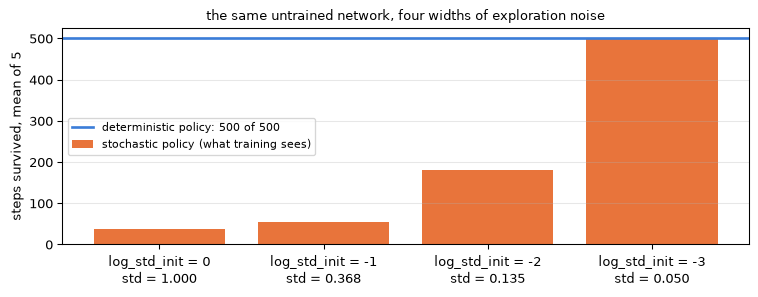

In [11]:
log_stds = (0.0, -1.0, -2.0, -3.0)
stoch = [survival(PPO("MlpPolicy", probe, verbose=0, seed=0, device="cpu",
                      policy_kwargs=dict(log_std_init=s)), probe, False) for s in log_stds]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar([f"log_std_init = {s:.0f}\nstd = {np.exp(s):.3f}" for s in log_stds], stoch, color="#e8743b",
       label="stochastic policy (what training sees)")
ax.axhline(500, color="#3b7dd8", lw=2, label="deterministic policy: 500 of 500")
ax.set_ylabel("steps survived, mean of 5"); ax.legend(fontsize=8, loc="center left"); ax.grid(axis="y", alpha=0.3)
ax.set_title("the same untrained network, four widths of exploration noise", fontsize=10)
fig.tight_layout(); plt.show()

The network is identical in every bar. Only the width of the
distribution changes, and it decides whether PPO’s first batch of data
is a robot standing or a robot on the floor.

------------------------------------------------------------------------

## That is the whole failure

The mean policy stands for the full episode. The **sampled** policy
falls in about forty steps.

So more than 90% of the experience PPO collects is a robot falling over.
It never sees the competent behaviour its own mean produces, and it
dutifully learns from the wreckage.

> A policy is a *distribution*. If the distribution is too wide, the
> data you gather describes a policy you would never deploy.

Turn the noise down and the failure disappears:

In [12]:
t0 = time.time()
quiet_env = G1WalkEnv()
quiet = PPO("MlpPolicy", quiet_env, verbose=0, seed=0, device="cpu",
            policy_kwargs=dict(log_std_init=-2.0))          # std 0.135 instead of 1.0
print(f"stochastic survival now : {survival(quiet, quiet_env, False):5.1f} of 500 steps")
quiet.learn(total_timesteps=30_000)
after_quiet, _ = evaluate_policy(quiet, quiet_env, n_eval_episodes=5, warn=False)
print(f"after 30k steps         : {after_quiet:7.1f}   (was {after:.1f} with the default noise)")

stochastic survival now : 179.8 of 500 steps
after 30k steps         :   776.2   (was 94.7 with the default noise)

------------------------------------------------------------------------

## But it still is not walking

The policy survives training now. It scores around the standing baseline
— which means it has learned **not to fall over**, and nothing more.

Walking is worth 1250. We are at roughly 780.

|                                    | return   |
|------------------------------------|----------|
| lunging policy (default noise)     | ~95      |
| standing still                     | 774      |
| **not falling, after the fix**     | ~780     |
| **walking at the target velocity** | **1250** |

Thirty thousand steps is **0.02%** of a real locomotion run; the
literature uses 150–200 million. We have removed a bug, not solved the
problem.

**Two different problems, and we have only fixed the first.**

| Problem | Fix | Week |
|------------------------|------------------------|------------------------|
| Exploration destroys a good policy | narrow the initial action distribution | today |
| The reward is only *approximately* what we want | take it apart term by term | 9 |
| 30k steps is nothing | 10⁸ steps, in parallel, on a GPU | 10 |
| One brittle solution | randomise the world it trains in | 11 |

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/08-ppo/lab_train.py          # torch + SB3: uv sync --extra rl
```

`G1WalkEnv` under a PPO policy from `CONFIGS`; `T` trains it in the
background (70 s for 30k steps) while the window keeps playing; `D`
switches the mean action for a sampled one; `ENTER` prints the action
std. **The code is complete**: `choose_action` is PPO’s own sampling,
explained.

| Step | Do | Right looks like |
|------------------------|------------------------|------------------------|
| 1 | `ENTER` | std 1.0; the deterministic robot stands 500 steps, return 774 |
| 2 | `D`; break `choose_action` | ~42 steps survived; the mean makes `D` do nothing; std × 3 falls at once |
| 3 | `T`, then `D` | trained on std 1.0 the deterministic robot is *worse*: 94, 47 steps |
| 4 | `2` (log_std_init −2), `D`, `T` | ~208 steps stochastic; trained 777 and 500 steps: not falling, not walking |
| 5 | log_std_init −4 | a prediction first; it will not walk either |

------------------------------------------------------------------------

## Lab class: `train.py`, two robots measured

``` bash
uv run weeks/08-ppo/train.py --log-std -2
uv run weeks/08-ppo/train.py --steps 0 --no-viewer
```

Evaluates the untrained policy both ways, trains with a progress line
every 5000 steps, evaluates both ways again, replays the trained mean
robot.

| log_std_init | untrained det. | untrained stoch. | trained det. | trained stoch. |
|---------------|---------------|---------------|---------------|---------------|
| 0 (std 1.0) | 774, 500 steps | 51, 42 steps | **94, 47 steps** | 37, 35 steps |
| −2 (std 0.135) | 774, 500 steps | 301, 208 steps | **777, 500 steps** | 240, 169 steps |

| Step | Does | Calls |
|------------------------|------------------------|------------------------|
| 1 | env and agent | `G1WalkEnv`, `PPO("MlpPolicy", …, log_std_init)` |
| 2 | evaluate: mean vs `sample_action` | `predict(deterministic=True)`, `policy.log_std` |
| 3 | train with progress | `learn(callback)`, `ep_info_buffer` |
| 6 | replay | `launch_viewer(passive=True)` |

------------------------------------------------------------------------

## Exercises

1.  **No baseline.** Delete the return standardisation from REINFORCE.
    How much worse is it? Explain via variance rather than bias.
2.  **Discount.** Set $\gamma = 0.9$ and $\gamma = 0.999$ on CartPole.
    Which trains faster and which reaches a better final policy?
3.  **Clipping is not the fix.** Train the humanoid with
    `clip_range=0.05`. It limits how far the policy moves per update —
    explain why that does *not* address data collected from a too-wide
    distribution.
4.  **Sweep the noise.** Train with `log_std_init` of 0, -1, -2 and -3.
    Plot initial stochastic episode length against the return after
    training. Where is the cliff?
5.  **Alive bonus.** Sweep the bonus from 0 to 2. Find the value at
    which standing still beats every attempt to walk. What does that say
    about shaping?
6.  **Honest baselines.** Report untrained return, hold-the-crouch
    return, and trained return for three seeds. Is the difference
    between them significant?

------------------------------------------------------------------------

## Next week

**09 — reward shaping.** We take a real locomotion reward apart term by
term, remove them one at a time, and catalogue the pathology each one
produces.

Today’s lunging robot is the first entry in that catalogue.